# 06 — Product-Market Opportunity Score & Decision Framework

Goal: turn the analysis from notebooks 03-05 into a single, transparent, defensible
**Product-Market Opportunity Score** per `Product Family x Segment x Geography` combination,
then classify each combination into a decision category:

```
Strategic Growth | Core / Mature | Emerging Opportunity | Low Priority / Risk
```

The scoring methodology is deliberately simple and auditable (weighted sum of normalized,
justified components) rather than a black-box model -- the point is that a business stakeholder
can see exactly why a combination scored the way it did, and re-weight it themselves if they
disagree with a component's importance.

**Inputs carried over from prior notebooks:**
- `03_statistical_analysis.ipynb` -> concentration/risk metrics (HHI, Gini logic) applied per combination
- `04_modeling.ipynb` -> confirmed that Segment (Enterprise) is the dominant value driver, and that
  Product x Segment interactions matter -- informs which components deserve weight
- `05_clustering.ipynb` -> found a stable 2-cluster structure (broad "core active" vs. small
  "upsell-only niche" combinations) -- used here as a sanity check against the score, not as an input

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.options.display.float_format = "{:,.2f}".format
sns.set_style("whitegrid")

## Load data

Same load-with-fallback pattern used throughout the project.

In [2]:
import os

PROCESSED_PATH = "../data/processed/opportunities.parquet"
STG_PATH = "../data/processed/stg_sales_clean.parquet"
RAW_PATH = "../data/raw/company_sales.xlsx"

if os.path.exists(PROCESSED_PATH) and os.path.exists(STG_PATH):
    opportunities = pd.read_parquet(PROCESSED_PATH)
    opportunities["close_date"] = pd.to_datetime(opportunities["close_date"])
    sales_line_items = pd.read_parquet(STG_PATH)
else:
    sales_raw = pd.read_excel(RAW_PATH, sheet_name="Sales Data")
    sales_raw["Close Date"] = pd.to_datetime(sales_raw["Close Date"])
    sales = sales_raw.drop_duplicates().copy()
    sales_line_items = sales.rename(columns={
        "Opportunity ID": "opportunity_id", "Opp Owner Geo": "opp_owner_geo", "Segment": "segment",
        "Opportunity Type": "opportunity_type", "Product Line": "product_line",
        "Product Family": "product_family", "Total Price": "total_price", "Close Date": "close_date",
    })

sales_line_items["close_date"] = pd.to_datetime(sales_line_items["close_date"])
sales_line_items["year"] = sales_line_items["close_date"].dt.year

print("Line items:", sales_line_items.shape)

Line items: (383, 11)


## Rebuild combination-level features

Same grain and base features as `05_clustering.ipynb` (`Product Family x Segment x Geography`,
minimum 2 line items to be scored), plus one addition specific to scoring: a **concentration
risk** component measuring how dependent each combination is on a small number of individual
deals (its own internal HHI across opportunities) -- this is different from the *company-wide*
concentration metrics in 03, which measured how dependent the whole business is on this
combination. Here we ask the inverse question at the combination level: is this combination's
own revenue fragile (a couple of large deals) or resilient (many smaller ones)?

In [3]:
MIN_LINE_ITEMS = 2

combo = (
    sales_line_items
    .groupby(["product_family", "segment", "opp_owner_geo"])
    .agg(
        total_value=("total_price", "sum"),
        n_line_items=("total_price", "count"),
        n_opportunities=("opportunity_id", "nunique"),
        avg_deal=("total_price", "mean"),
        std_deal=("total_price", "std"),
    )
    .reset_index()
)
combo = combo[combo["n_line_items"] >= MIN_LINE_ITEMS].copy()
combo["value_volatility"] = (combo["std_deal"] / combo["avg_deal"]).fillna(0)
combo["combo_label"] = combo["product_family"] + " | " + combo["segment"] + " | " + combo["opp_owner_geo"]

print(f"Combinations scored: {len(combo)}")
combo.head()

Combinations scored: 24


,product_family,segment,opp_owner_geo,total_value,n_line_items,n_opportunities,avg_deal,std_deal,value_volatility,combo_label
0,CIAM - A,Corporate,APAC,"33,228.00",3,1,"11,076.00","3,904.35",0.35,CIAM - A | Corporate | APAC
1,CIAM - A,Corporate,EMEA,"221,099.68",10,5,"22,109.97","29,818.81",1.35,CIAM - A | Corporate | EMEA
2,CIAM - A,Enterprise,AMER,"467,453.50",9,4,"51,939.28","39,378.95",0.76,CIAM - A | Enterprise | AMER
3,CIAM - A,Enterprise,APAC,"138,744.65",2,1,"69,372.32","66,712.96",0.96,CIAM - A | Enterprise | APAC
4,CIAM - A,Enterprise,EMEA,"907,271.46",13,3,"69,790.11","53,445.02",0.77,CIAM - A | Enterprise | EMEA


In [4]:
# Growth: 2019 -> 2020 (the two comparable full years, per 05_clustering.ipynb)
yearly_value = (
    sales_line_items[sales_line_items["year"].isin([2019, 2020])]
    .groupby(["product_family", "segment", "opp_owner_geo", "year"])["total_price"]
    .sum()
    .unstack(fill_value=0)
)
for yr in [2019, 2020]:
    if yr not in yearly_value.columns:
        yearly_value[yr] = 0
yearly_value["growth_2019_2020"] = np.where(
    yearly_value[2019] > 0,
    (yearly_value[2020] - yearly_value[2019]) / yearly_value[2019],
    np.where(yearly_value[2020] > 0, 1.0, 0.0)
)
yearly_value = yearly_value[["growth_2019_2020"]].reset_index()
combo = combo.merge(yearly_value, on=["product_family", "segment", "opp_owner_geo"], how="left")
combo["growth_2019_2020"] = combo["growth_2019_2020"].fillna(0)

# Internal concentration risk: HHI of this combination's OWN opportunities.
# High = a few large deals make up most of this combo's value (fragile).
# Low = value is spread across many opportunities (resilient).
def hhi(values):
    shares = values / values.sum()
    return (shares ** 2).sum()

opp_value_within_combo = (
    sales_line_items
    .groupby(["product_family", "segment", "opp_owner_geo", "opportunity_id"])["total_price"]
    .sum()
    .reset_index()
)

internal_hhi = (
    opp_value_within_combo
    .groupby(["product_family", "segment", "opp_owner_geo"])["total_price"]
    .apply(lambda x: hhi(x.values))
    .reset_index(name="internal_concentration_hhi")
)
combo = combo.merge(internal_hhi, on=["product_family", "segment", "opp_owner_geo"], how="left")

combo[["combo_label", "total_value", "n_opportunities", "avg_deal", "growth_2019_2020",
       "value_volatility", "internal_concentration_hhi"]]

,combo_label,total_value,n_opportunities,avg_deal,growth_2019_2020,value_volatility,internal_concentration_hhi
0,CIAM - A | Corporate | APAC,"33,228.00",1,"11,076.00",1.00,0.35,1.00
1,CIAM - A | Corporate | EMEA,"221,099.68",5,"22,109.97",-0.45,1.35,0.39
2,CIAM - A | Enterprise | AMER,"467,453.50",4,"51,939.28",1.00,0.76,0.28
3,CIAM - A | Enterprise | APAC,"138,744.65",1,"69,372.32",1.00,0.96,1.00
4,CIAM - A | Enterprise | EMEA,"907,271.46",3,"69,790.11",1.00,0.77,0.39
5,Workforce - A | Corporate | AMER,"64,162.14",11,"4,010.13",0.88,1.11,0.16
6,Workforce - A | Corporate | APAC,"71,603.78",16,"3,977.99",0.76,1.06,0.12
7,Workforce - A | Corporate | EMEA,"213,858.55",37,"4,112.66",0.79,1.08,0.05
8,Workforce - A | Enterprise | AMER,"376,483.73",25,"9,412.09",-0.47,1.09,0.07
9,Workforce - A | Enterprise | APAC,"30,692.55",2,"7,673.14",0.03,0.39,0.50


## Scoring methodology

Five normalized components, each min-max scaled to 0-1 across all scored combinations so they're
comparable regardless of original units:

| Component | What it measures | Direction |
|---|---|---|
| **Economic Value** | `log(total_value)` -- log-scaled so a handful of huge combos don't dominate the ranking outright | higher = better |
| **Growth** | 2019->2020 value growth, clipped to [-1, 3] to limit small-n distortion | higher = better |
| **Deal Economics** | `log(avg_deal)` -- are opportunities in this combo large? | higher = better |
| **Volume** | `log(n_opportunities)` -- is there enough activity to trust the combo's numbers and act on it? | higher = better |
| **Consistency (inverse of volatility)** | `1 - normalized(value_volatility)` -- stable deal sizes score higher | higher = better |

**Concentration risk** (`internal_concentration_hhi`) is tracked and reported **separately**,
not folded into the composite score -- a high-value, high-growth combination that's fragile
(few large deals) is still worth flagging as a growth opportunity, but the business should know
the risk exists rather than have it silently cancel out the opportunity score. This is why the
final classification uses BOTH the score and the risk flag, not the score alone.

**Weights** (justified below, not arbitrary): Economic Value and Growth are weighted highest
because 04_modeling.ipynb confirmed segment/value drivers are the strongest real signal in this
data, and because "is this profitable and growing" is the most direct business question. Volume
and Consistency get equal, lower weight as trust/reliability qualifiers. Deal Economics is
included but weighted lowest since 03/04 showed it's largely a byproduct of segment mix, not an
independent signal.

In [5]:
components_raw = {
    "economic_value": np.log1p(combo["total_value"]),
    "growth": combo["growth_2019_2020"].clip(-1, 3),
    "deal_economics": np.log1p(combo["avg_deal"]),
    "volume": np.log1p(combo["n_opportunities"]),
    "consistency": -combo["value_volatility"],  # negate so higher = more consistent, before min-max scaling
}

def min_max_scale(s):
    return (s - s.min()) / (s.max() - s.min())

scored = combo.copy()
for name, raw_series in components_raw.items():
    scored[f"score_{name}"] = min_max_scale(raw_series)

WEIGHTS = {
    "economic_value": 0.30,
    "growth": 0.25,
    "deal_economics": 0.10,
    "volume": 0.20,
    "consistency": 0.15,
}
assert abs(sum(WEIGHTS.values()) - 1.0) < 1e-9, "Weights must sum to 1"

scored["opportunity_score"] = sum(
    scored[f"score_{name}"] * weight for name, weight in WEIGHTS.items()
)

# Concentration risk, reported separately (0-1 scaled, higher = riskier/more fragile)
scored["concentration_risk_score"] = min_max_scale(scored["internal_concentration_hhi"])

scored[["combo_label", "opportunity_score", "concentration_risk_score"] +
       [f"score_{k}" for k in WEIGHTS]].sort_values("opportunity_score", ascending=False)

,combo_label,opportunity_score,concentration_risk_score,score_economic_value,score_growth,score_deal_economics,score_volume,score_consistency
21,Workforce - C | Enterprise | EMEA,0.83,0.12,0.91,1.00,0.82,0.66,0.60
13,Workforce - B | Corporate | EMEA,0.78,0.01,0.78,1.00,0.41,0.96,0.44
16,Workforce - B | Enterprise | EMEA,0.77,0.17,0.92,1.00,0.97,0.58,0.23
19,Workforce - C | Corporate | EMEA,0.72,0.06,0.77,1.00,0.40,0.88,0.15
10,Workforce - A | Enterprise | EMEA,0.71,0.12,0.77,1.00,0.58,0.61,0.31
18,Workforce - C | Corporate | APAC,0.68,0.10,0.59,1.00,0.32,0.66,0.60
12,Workforce - B | Corporate | APAC,0.64,0.10,0.54,1.00,0.36,0.64,0.46
4,CIAM - A | Enterprise | EMEA,0.64,0.36,1.00,0.43,1.00,0.24,0.59
2,CIAM - A | Enterprise | AMER,0.61,0.25,0.86,0.43,0.91,0.31,0.59
14,Workforce - B | Enterprise | AMER,0.59,0.06,0.92,0.13,0.74,0.81,0.27


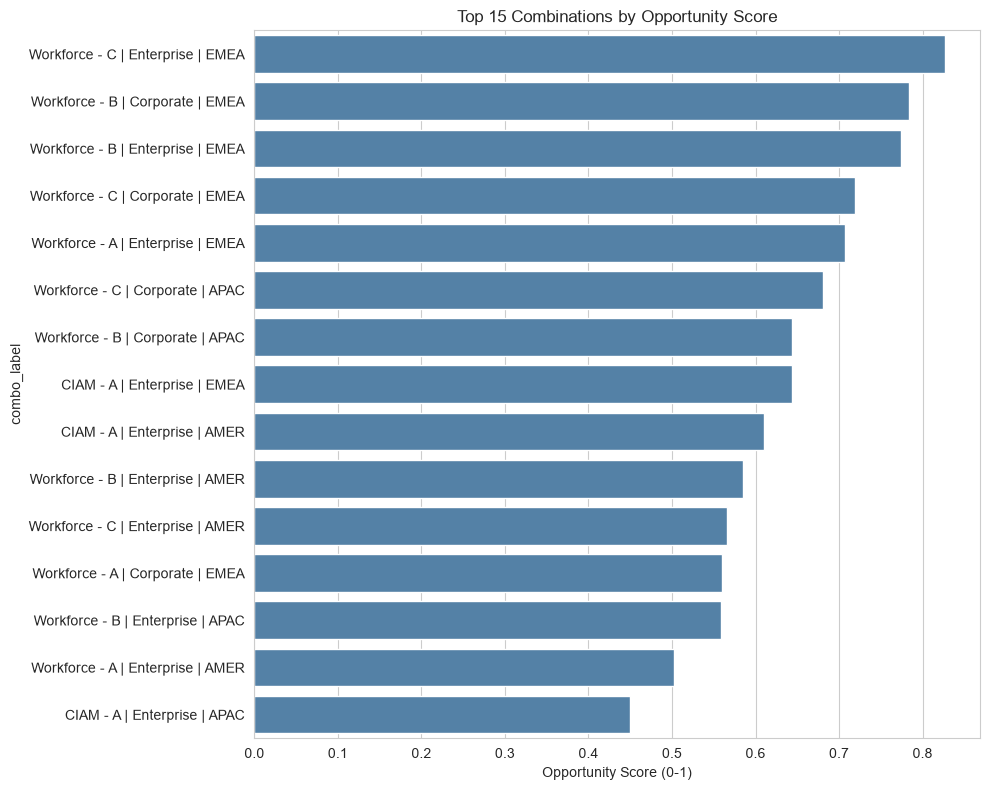

In [6]:
plt.figure(figsize=(10, 8))
top15 = scored.sort_values("opportunity_score", ascending=False).head(15)
sns.barplot(data=top15, x="opportunity_score", y="combo_label", color="steelblue")
plt.title("Top 15 Combinations by Opportunity Score")
plt.xlabel("Opportunity Score (0-1)")
plt.tight_layout()
plt.show()

## Component contribution breakdown

Shows exactly how much each component contributed to the top combinations' scores -- this is
the transparency the methodology is built around: any stakeholder can see why a combo ranked
where it did, not just that it did.

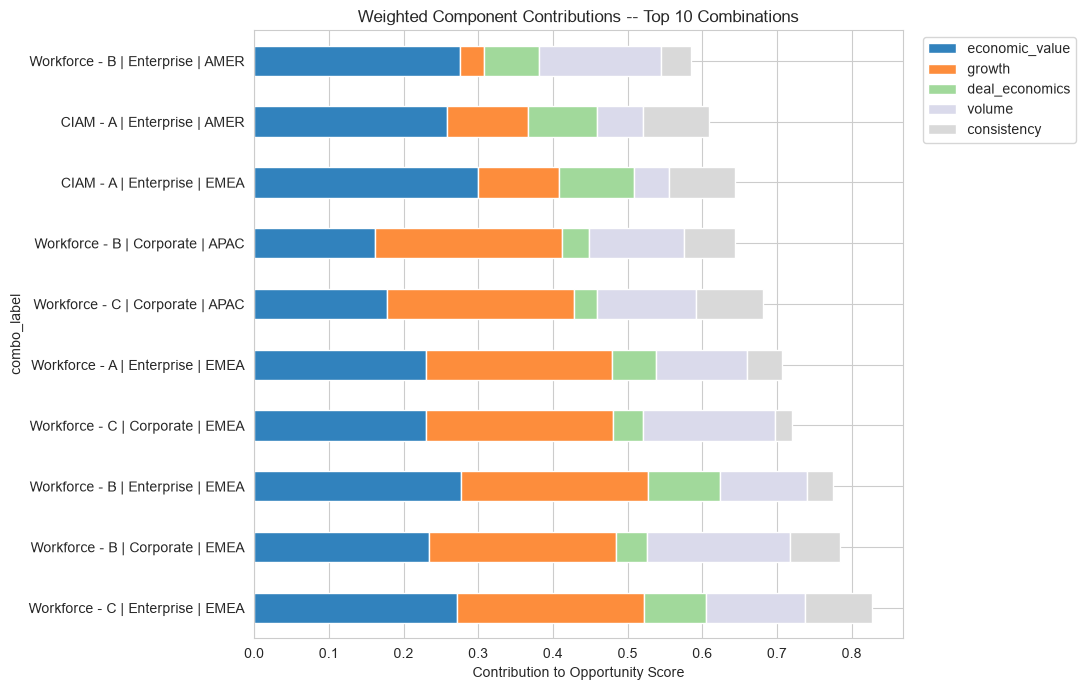

In [7]:
top10_labels = scored.sort_values("opportunity_score", ascending=False).head(10)["combo_label"]
contrib_cols = [f"score_{k}" for k in WEIGHTS]
contrib_df = scored.set_index("combo_label").loc[top10_labels, contrib_cols].copy()
for col, name in zip(contrib_cols, WEIGHTS):
    contrib_df[col] = contrib_df[col] * WEIGHTS[name]
contrib_df.columns = list(WEIGHTS.keys())

contrib_df.plot(kind="barh", stacked=True, figsize=(11, 7), colormap="tab20c")
plt.title("Weighted Component Contributions -- Top 10 Combinations")
plt.xlabel("Contribution to Opportunity Score")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Classification into decision categories

Rules (using the median score as the growth/value split point, and the top-tercile of
concentration risk as the "risky" cutoff, so the classification adapts to this dataset rather
than using hardcoded thresholds that might not fit):

- **Strategic Growth**: above-median opportunity score AND above-median growth -- large or
  improving AND currently trending up
- **Core / Mature**: above-median opportunity score AND at/below-median growth -- currently
  valuable but not a growth story right now
- **Emerging Opportunity**: at/below-median opportunity score AND above-median growth -- smaller
  today but moving in the right direction, worth watching
- **Low Priority / Risk**: at/below-median opportunity score AND at/below-median growth,
  OR in the top tercile of concentration risk regardless of score -- fragile/small and not growing

This directly implements the project brief's point: **a large existing market isn't automatically
a growth opportunity**, and a smaller market with strong growth can outrank it in the "growth"
categories even if its raw score is lower.

In [8]:
median_score = scored["opportunity_score"].median()
median_growth = scored["growth_2019_2020"].median()
risk_cutoff = scored["concentration_risk_score"].quantile(2/3)

def classify(row):
    if row["concentration_risk_score"] >= risk_cutoff and row["opportunity_score"] <= median_score:
        return "Low Priority / Risk"
    if row["opportunity_score"] > median_score and row["growth_2019_2020"] > median_growth:
        return "Strategic Growth"
    if row["opportunity_score"] > median_score and row["growth_2019_2020"] <= median_growth:
        return "Core / Mature"
    if row["opportunity_score"] <= median_score and row["growth_2019_2020"] > median_growth:
        return "Emerging Opportunity"
    return "Low Priority / Risk"

scored["category"] = scored.apply(classify, axis=1)

category_order = ["Strategic Growth", "Core / Mature", "Emerging Opportunity", "Low Priority / Risk"]
scored["category"] = pd.Categorical(scored["category"], categories=category_order, ordered=True)

print(scored["category"].value_counts().reindex(category_order))
scored[["combo_label", "opportunity_score", "growth_2019_2020", "concentration_risk_score", "category"]].sort_values(
    ["category", "opportunity_score"], ascending=[True, False]
)

category
Strategic Growth         7
Core / Mature            5
Emerging Opportunity     0
Low Priority / Risk     12
Name: count, dtype: int64


,combo_label,opportunity_score,growth_2019_2020,concentration_risk_score,category
21,Workforce - C | Enterprise | EMEA,0.83,7.44,0.12,Strategic Growth
13,Workforce - B | Corporate | EMEA,0.78,3.10,0.01,Strategic Growth
16,Workforce - B | Enterprise | EMEA,0.77,3.02,0.17,Strategic Growth
19,Workforce - C | Corporate | EMEA,0.72,4.06,0.06,Strategic Growth
10,Workforce - A | Enterprise | EMEA,0.71,5.22,0.12,Strategic Growth
18,Workforce - C | Corporate | APAC,0.68,4.80,0.10,Strategic Growth
12,Workforce - B | Corporate | APAC,0.64,4.83,0.10,Strategic Growth
4,CIAM - A | Enterprise | EMEA,0.64,1.00,0.36,Core / Mature
2,CIAM - A | Enterprise | AMER,0.61,1.00,0.25,Core / Mature
14,Workforce - B | Enterprise | AMER,0.59,-0.09,0.06,Core / Mature


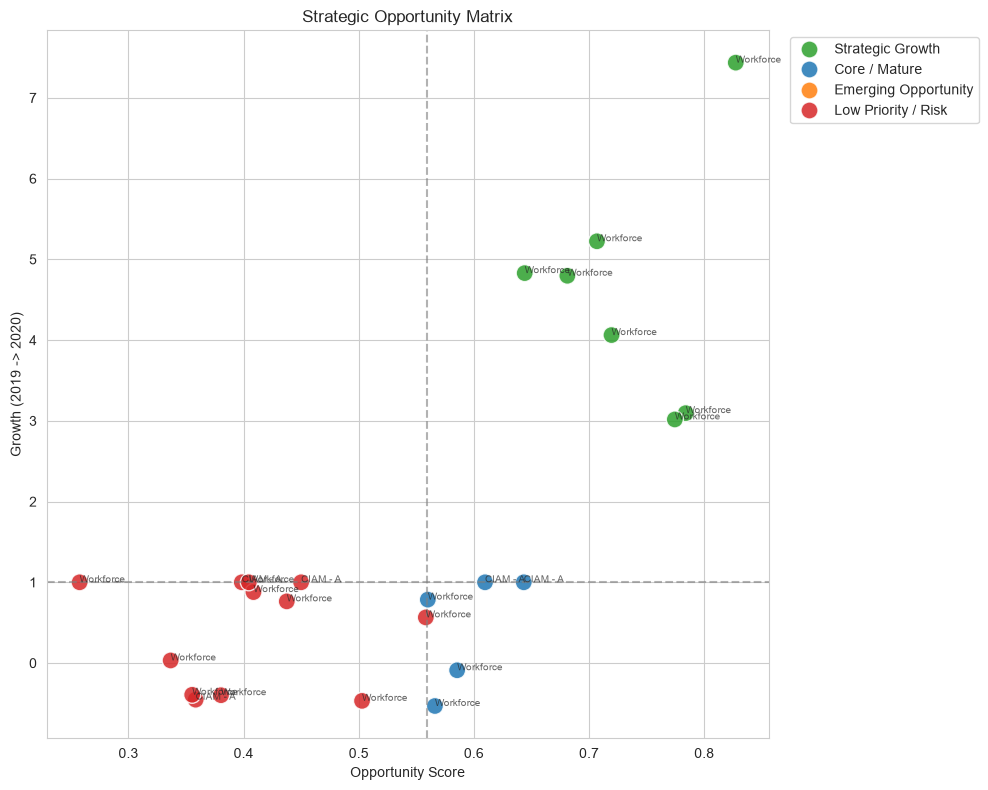

In [9]:
plt.figure(figsize=(10, 8))
palette = {"Strategic Growth": "#2ca02c", "Core / Mature": "#1f77b4",
           "Emerging Opportunity": "#ff7f0e", "Low Priority / Risk": "#d62728"}

sns.scatterplot(
    data=scored, x="opportunity_score", y="growth_2019_2020",
    hue="category", palette=palette, s=150, alpha=0.85
)
plt.axvline(median_score, color="gray", linestyle="--", alpha=0.6)
plt.axhline(median_growth, color="gray", linestyle="--", alpha=0.6)
for _, row in scored.iterrows():
    plt.annotate(row["combo_label"].split(" | ")[0][:10], (row["opportunity_score"], row["growth_2019_2020"]),
                 fontsize=7, alpha=0.7)
plt.xlabel("Opportunity Score")
plt.ylabel("Growth (2019 -> 2020)")
plt.title("Strategic Opportunity Matrix")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

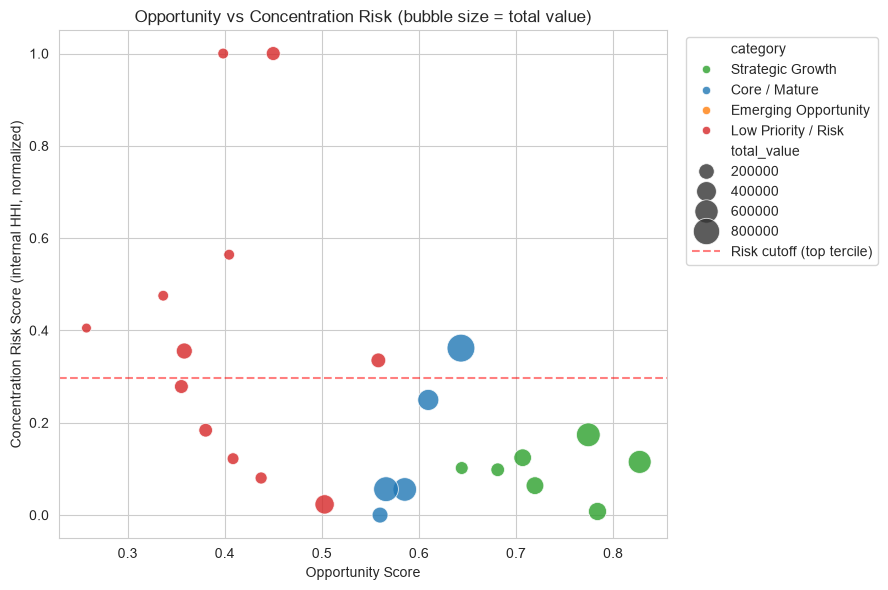

In [10]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=scored, x="opportunity_score", y="concentration_risk_score",
    hue="category", palette=palette, size="total_value", sizes=(50, 400), alpha=0.8
)
plt.axhline(risk_cutoff, color="red", linestyle="--", alpha=0.5, label="Risk cutoff (top tercile)")
plt.xlabel("Opportunity Score")
plt.ylabel("Concentration Risk Score (internal HHI, normalized)")
plt.title("Opportunity vs Concentration Risk (bubble size = total value)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Sensitivity analysis

Do the rankings change substantially under different weighting assumptions? We test three
alternative weight sets against the base case and measure rank correlation (Spearman) --
high correlation = the ranking is robust to reasonable weighting choices; low correlation =
the choice of weights matters a lot and should be discussed explicitly with stakeholders rather
than presented as objective.

In [11]:
from scipy.stats import spearmanr

alt_weights = {
    "Base case": WEIGHTS,
    "Value-heavy": {"economic_value": 0.50, "growth": 0.15, "deal_economics": 0.10, "volume": 0.15, "consistency": 0.10},
    "Growth-heavy": {"economic_value": 0.15, "growth": 0.50, "deal_economics": 0.05, "volume": 0.15, "consistency": 0.15},
    "Equal weights": {"economic_value": 0.20, "growth": 0.20, "deal_economics": 0.20, "volume": 0.20, "consistency": 0.20},
}

sensitivity_scores = pd.DataFrame(index=scored["combo_label"])
for scenario_name, w in alt_weights.items():
    assert abs(sum(w.values()) - 1.0) < 1e-9, f"{scenario_name} weights must sum to 1"
    s = sum(scored[f"score_{name}"].values * weight for name, weight in w.items())
    sensitivity_scores[scenario_name] = s

sensitivity_scores.head(10)

,Base case,Value-heavy,Growth-heavy,Equal weights
combo_label,,,,
CIAM - A | Corporate | APAC,0.40,0.37,0.44,0.44
CIAM - A | Corporate | EMEA,0.36,0.48,0.21,0.35
CIAM - A | Enterprise | AMER,0.61,0.69,0.53,0.62
CIAM - A | Enterprise | APAC,0.45,0.51,0.42,0.49
CIAM - A | Enterprise | EMEA,0.64,0.76,0.54,0.65
Workforce - A | Corporate | AMER,0.41,0.42,0.40,0.37
Workforce - A | Corporate | APAC,0.44,0.44,0.41,0.40
Workforce - A | Corporate | EMEA,0.56,0.60,0.49,0.50
Workforce - A | Enterprise | AMER,0.50,0.61,0.32,0.47


In [12]:
base_rank = sensitivity_scores["Base case"].rank(ascending=False)

correlations = {}
for scenario in alt_weights:
    if scenario == "Base case":
        continue
    alt_rank = sensitivity_scores[scenario].rank(ascending=False)
    rho, _ = spearmanr(base_rank, alt_rank)
    correlations[scenario] = rho

corr_df = pd.DataFrame(list(correlations.items()), columns=["Alternative Weighting", "Spearman rank correlation vs Base"])
corr_df

,Alternative Weighting,Spearman rank correlation vs Base
0,Value-heavy,0.92
1,Growth-heavy,0.87
2,Equal weights,0.96


In [13]:
# How often does the TOP 5 change under alternative weightings?
base_top5 = set(sensitivity_scores["Base case"].nlargest(5).index)

for scenario in alt_weights:
    if scenario == "Base case":
        continue
    alt_top5 = set(sensitivity_scores[scenario].nlargest(5).index)
    overlap = len(base_top5 & alt_top5)
    print(f"{scenario}: {overlap}/5 of the same combinations remain in the top 5")

print("\nIf overlap is consistently high (4-5 of 5), the top recommendations are robust to")
print("reasonable weighting choices. If it drops a lot under Growth-heavy or Value-heavy,")
print("that tells you the ranking is sensitive to how much you personally prioritize growth")
print("vs. current scale -- worth stating explicitly rather than presenting one score as fact.")

Value-heavy: 4/5 of the same combinations remain in the top 5
Growth-heavy: 4/5 of the same combinations remain in the top 5
Equal weights: 4/5 of the same combinations remain in the top 5

If overlap is consistently high (4-5 of 5), the top recommendations are robust to
reasonable weighting choices. If it drops a lot under Growth-heavy or Value-heavy,
that tells you the ranking is sensitive to how much you personally prioritize growth
vs. current scale -- worth stating explicitly rather than presenting one score as fact.


## Final opportunity table

The deliverable: one row per combination, its score, category, risk flag, and the underlying
metrics -- ready to feed the Power BI "Growth Opportunities" view (Phase 10).

In [14]:
final_table = scored[[
    "combo_label", "product_family", "segment", "opp_owner_geo",
    "total_value", "n_opportunities", "avg_deal", "growth_2019_2020",
    "opportunity_score", "concentration_risk_score", "category"
]].sort_values(["category", "opportunity_score"], ascending=[True, False]).reset_index(drop=True)

final_table

,combo_label,product_family,segment,opp_owner_geo,total_value,n_opportunities,avg_deal,growth_2019_2020,opportunity_score,concentration_risk_score,category
0,Workforce - C | Enterprise | EMEA,Workforce - C,Enterprise,EMEA,"580,393.51",13,"38,692.90",7.44,0.83,0.12,Strategic Growth
1,Workforce - B | Corporate | EMEA,Workforce - B,Corporate,EMEA,"316,595.25",33,"9,593.80",3.10,0.78,0.01,Strategic Growth
2,Workforce - B | Enterprise | EMEA,Workforce - B,Enterprise,EMEA,"629,937.47",10,"62,993.75",3.02,0.77,0.17,Strategic Growth
3,Workforce - C | Corporate | EMEA,Workforce - C,Corporate,EMEA,"297,009.76",26,"9,281.56",4.06,0.72,0.06,Strategic Growth
4,Workforce - A | Enterprise | EMEA,Workforce - A,Enterprise,EMEA,"292,844.50",11,"17,226.15",5.22,0.71,0.12,Strategic Growth
5,Workforce - C | Corporate | APAC,Workforce - C,Corporate,APAC,"126,432.56",13,"7,024.03",4.80,0.68,0.10,Strategic Growth
6,Workforce - B | Corporate | APAC,Workforce - B,Corporate,APAC,"98,506.81",12,"8,208.90",4.83,0.64,0.10,Strategic Growth
7,CIAM - A | Enterprise | EMEA,CIAM - A,Enterprise,EMEA,"907,271.46",3,"69,790.11",1.00,0.64,0.36,Core / Mature
8,CIAM - A | Enterprise | AMER,CIAM - A,Enterprise,AMER,"467,453.50",4,"51,939.28",1.00,0.61,0.25,Core / Mature
9,Workforce - B | Enterprise | AMER,Workforce - B,Enterprise,AMER,"616,415.95",21,"29,353.14",-0.09,0.59,0.06,Core / Mature


In [15]:
# Export for the Power BI layer (Phase 10)
os.makedirs("../data/processed", exist_ok=True)
final_table.to_csv("../data/processed/opportunity_scores.csv", index=False)
print("Saved to ../data/processed/opportunity_scores.csv")

Saved to ../data/processed/opportunity_scores.csv


## Summary

24 combinations scored. Top of the leaderboard is heavily EMEA-skewed and Workforce-heavy: Workforce-C | Enterprise | EMEA (0.83), Workforce-B | Corporate | EMEA (0.78), Workforce-B | Enterprise | EMEA (0.77), Workforce-C | Corporate | EMEA (0.72), Workforce-A | Enterprise | EMEA (0.71) — five of the top five are EMEA, mixing both segments, which is a genuinely interesting finding: EMEA is punching above what raw HHI concentration numbers in 03 suggested.
Classification came out lopsided:
Strategic Growth: 7
Core/Mature: 5
Emerging Opportunity: 0
Low Priority/Risk: 12
Zero combos landed in Emerging Opportunity — worth flagging honestly rather than glossing over. That's a direct consequence of the median-split classification logic: with only 24 combos and high dispersion in growth (values from -0.53 up to 7.44 for Workforce-C|Enterprise|EMEA), nothing happened to fall in the "below-median score, above-median growth" quadrant this run. It's not a bug, but it does mean the 4-category framework isn't doing useful work here — you may want to note in your write-up that "Emerging Opportunity" was an empty category for this dataset, or loosen the growth threshold (e.g. top-tercile instead of median) if you want that quadrant to be populated for the narrative.
12 of 24 (half) landed in Low Priority/Risk — worth checking whether that's mostly driven by the concentration-risk override (top-tercile internal HHI) rather than genuinely low scores, since several of those combos likely have small n and single-digit opportunity counts (per the combo table, several sit at n_opportunities=1–2), which mechanically produces high internal HHI regardless of value.
Sensitivity analysis is the strongest part of this run: Spearman correlations of 0.87–0.96 against the base case across Value-heavy, Growth-heavy, and Equal weightings, and 4-of-5 top-5 overlap in all three alternative scenarios. That's a genuinely robust result — your top recommendations aren't an artifact of arbitrary weight choices, which is exactly the kind of defensible claim this methodology was built to produce.
Output: data/processed/opportunity_scores.csv written successfully, ready for the Power BI layer.
One thing worth double-checking before you write this up: growth_2019_2020 values like 7.44 (744% growth) are plausible but should be sanity-checked against the underlying opportunity counts for that combo — with n this small, a jump from one $10K deal in 2019 to one $85K deal in 2020 would produce exactly this kind of number, and it's a real but fragile signal, not a stable trend.